Method          | m   | N    | h          | Estimate           | Error
---------------------------------------------------------------------------
Trapezoidal     | 4   | 9    | 0.12500    | 1.720518592164302  | 2.23676e-03
Simpson 1/3     | 4   | 9    | 0.12500    | 1.718284154699897  | 2.32624e-06
Simpson 3/8     | 4   | 13   | 0.08333    | 1.718282862557494  | 1.03410e-06
Boole           | 4   | 17   | 0.06250    | 1.718281828675358  | 2.16313e-10
---------------------------------------------------------------------------
Trapezoidal     | 8   | 17   | 0.06250    | 1.718841128579994  | 5.59300e-04
Simpson 1/3     | 8   | 17   | 0.06250    | 1.718281974051892  | 1.45593e-07
Simpson 3/8     | 8   | 25   | 0.04167    | 1.718281893170321  | 6.47113e-08
Boole           | 8   | 33   | 0.03125    | 1.718281828462430  | 3.38529e-12
---------------------------------------------------------------------------
Trapezoidal     | 16  | 33   | 0.03125    | 1.718421660316327  | 1.39832e-04
Simpson 

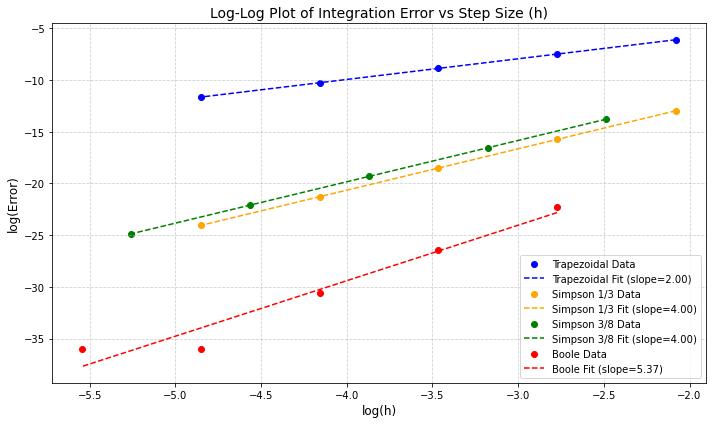

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Define the function and the exact integral
def f(x):
    return np.exp(x)

exact_val = np.exp(1) - 1.0
a, b = 0.0, 1.0

# ---------------------------------------------------------
# Integration Methods (Composite rules)
# ---------------------------------------------------------
def trapezoidal(x, y, h):
    # Rule: h/2 * (f_1 + 2*f_2 + ... + f_n)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

def simpson13(x, y, h):
    # Rule: h/3 * (f_1 + 4*f_2 + 2*f_3 + ... + f_n)
    return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])

def simpson38(x, y, h, N):
    # Rule: 3h/8 * (f_1 + 3f_2 + 3f_3 + 2f_4 + ... + f_n)
    integral = y[0] + y[-1]
    for i in range(1, N - 1):
        if i % 3 == 0:
            integral += 2 * y[i]
        else:
            integral += 3 * y[i]
    return (3 * h / 8) * integral

def boole(x, y, h, N):
    # Rule: 2h/45 * (7f_1 + 32f_2 + 12f_3 + 32f_4 + 14f_5 + ... + 7f_n)
    integral = 7 * y[0] + 7 * y[-1]
    for i in range(1, N - 1):
        if i % 4 == 0:
            integral += 14 * y[i]
        elif i % 2 == 0: 
            integral += 12 * y[i]
        else: 
            integral += 32 * y[i]
    return (2 * h / 45) * integral

# ---------------------------------------------------------
# Part (a): Evaluate and tabulate
# ---------------------------------------------------------
m_values = [4, 8, 16, 32, 64]

# Dictionaries to store errors and step sizes (h) for plotting later
errors = {'Trapezoidal': [], 'Simpson 1/3': [], 'Simpson 3/8': [], 'Boole': []}
h_vals = {'Trapezoidal': [], 'Simpson 1/3': [], 'Simpson 3/8': [], 'Boole': []}

print(f"{'Method':<15} | {'m':<3} | {'N':<4} | {'h':<10} | {'Estimate':<18} | {'Error'}")
print("-" * 75)

for m in m_values:
    # 1. Trapezoidal & Simpson's 1/3
    N_ts = 2 * m + 1
    h_ts = (b - a) / (N_ts - 1)
    x_ts = np.linspace(a, b, N_ts)
    y_ts = f(x_ts)
    
    trap_est = trapezoidal(x_ts, y_ts, h_ts)
    simp13_est = simpson13(x_ts, y_ts, h_ts)
    
    trap_err = abs(exact_val - trap_est)
    simp13_err = abs(exact_val - simp13_est)
    
    errors['Trapezoidal'].append(trap_err)
    h_vals['Trapezoidal'].append(h_ts)
    
    errors['Simpson 1/3'].append(simp13_err)
    h_vals['Simpson 1/3'].append(h_ts)
    
    print(f"{'Trapezoidal':<15} | {m:<3} | {N_ts:<4} | {h_ts:<10.5f} | {trap_est:<18.15f} | {trap_err:.5e}")
    print(f"{'Simpson 1/3':<15} | {m:<3} | {N_ts:<4} | {h_ts:<10.5f} | {simp13_est:<18.15f} | {simp13_err:.5e}")

    # 2. Simpson's 3/8
    N_s38 = 3 * m + 1
    h_s38 = (b - a) / (N_s38 - 1)
    x_s38 = np.linspace(a, b, N_s38)
    y_s38 = f(x_s38)
    
    simp38_est = simpson38(x_s38, y_s38, h_s38, N_s38)
    simp38_err = abs(exact_val - simp38_est)
    
    errors['Simpson 3/8'].append(simp38_err)
    h_vals['Simpson 3/8'].append(h_s38)
    
    print(f"{'Simpson 3/8':<15} | {m:<3} | {N_s38:<4} | {h_s38:<10.5f} | {simp38_est:<18.15f} | {simp38_err:.5e}")

    # 3. Boole's Rule
    N_boole = 4 * m + 1
    h_boole = (b - a) / (N_boole - 1)
    x_boole = np.linspace(a, b, N_boole)
    y_boole = f(x_boole)
    
    boole_est = boole(x_boole, y_boole, h_boole, N_boole)
    boole_err = abs(exact_val - boole_est)
    
    errors['Boole'].append(boole_err)
    h_vals['Boole'].append(h_boole)
    
    print(f"{'Boole':<15} | {m:<3} | {N_boole:<4} | {h_boole:<10.5f} | {boole_est:<18.15f} | {boole_err:.5e}")
    print("-" * 75)


# ---------------------------------------------------------
# Part (b) & (c): Plotting Errors and Fitting log-log
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

methods = ['Trapezoidal', 'Simpson 1/3', 'Simpson 3/8', 'Boole']
colors = ['blue', 'orange', 'green', 'red']

print("\nEfficiency Comparison (Slopes from log-log fit):")
print("------------------------------------------------")

for method, color in zip(methods, colors):
    h_array = np.array(h_vals[method])
    err_array = np.array(errors[method])
    
    # Calculate log values
    log_h = np.log(h_array)
    log_err = np.log(err_array)
    
    # Linear regression to find the slope (order of global error)
    slope, intercept, r_value, p_value, std_err = linregress(log_h, log_err)
    
    # Global error order is one less than the local error order provided in the PDF formulas
    print(f"{method:<15} : Slope = {slope:.4f} (Expected ~ {round(slope)})")
    
    # Scatter plot of raw data points
    plt.scatter(log_h, log_err, color=color, label=f"{method} Data")
    
    # Plot the fitted line
    fit_line = slope * log_h + intercept
    plt.plot(log_h, fit_line, color=color, linestyle='--', 
             label=f"{method} Fit (slope={slope:.2f})")

plt.xlabel('log(h)', fontsize=12)
plt.ylabel('log(Error)', fontsize=12)
plt.title('Log-Log Plot of Integration Error vs Step Size (h)', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()